In [1]:
# First overengineered graph

In [7]:
from langgraph.graph import StateGraph, START, END
from src.models.state import AgentState
from src.agent.nodes import (
    validate_input, parse_gpx, fetch_weather, generate_verdict, error_handler,
    resolve_text_query,
    rag_enrichment, alternatives_agent, merge_enrichment,
)
from src.agent.routing import route_after_validate, route_after_parse, route_after_weather

In [ ]:
def build_graph() -> StateGraph:
    graph = StateGraph(AgentState)
    graph.add_edge(START, 'validate_input')

    graph.add_node('validate_input', validate_input)
    graph.add_node('parse_gpx', parse_gpx)
    graph.add_node('fetch_weather', fetch_weather)
    graph.add_node('generate_verdict', generate_verdict)
    graph.add_node('error_handler', error_handler)
    graph.add_node('resolve_text_query', resolve_text_query)
    graph.add_node('rag_enrichment', rag_enrichment)
    graph.add_node('alternatives_agent', alternatives_agent)
    graph.add_node('merge_enrichment', merge_enrichment)

    graph.add_conditional_edges('validate_input', route_after_validate, {"parse_gpx": "parse_gpx", "resolve_text_query": "resolve_text_query", "error_handler": "error_handler"})
    graph.add_conditional_edges('parse_gpx', route_after_parse, {'fetch_weather': 'fetch_weather', 'error_handler': 'error_handler'})
    graph.add_conditional_edges('fetch_weather', route_after_weather, {"generate_verdict": "generate_verdict", "error_handler": "error_handler"})
    graph.add_conditional_edges('resolve_text_query', route_after_parse, {"fetch_weather": "fetch_weather", "error_handler": "error_handler"})
    graph.add_edge("generate_verdict", "rag_enrichment")
    graph.add_edge("generate_verdict", "alternatives_agent")
    graph.add_edge("rag_enrichment", "merge_enrichment")
    graph.add_edge("alternatives_agent", "merge_enrichment")
    graph.add_edge("error_handler", END)
    graph.add_edge("merge_enrichment", END)
    return graph

In [40]:
app = build_graph().compile()

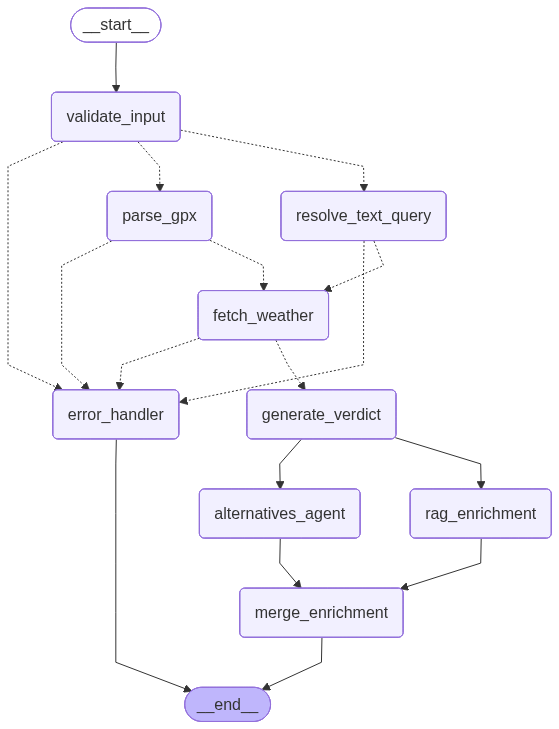

In [41]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [ ]:
# New graph simpler 2026-03-02

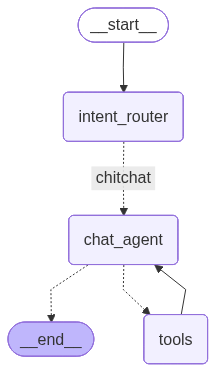

In [ ]:
from langchain_core.messages import AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph
from langgraph.prebuilt import ToolNode

from src.agent.nodes import chat_agent, extract_url_from_messages
from src.agent.tools import analyze_route, rag_query, search_routes
from src.models.state import AgentState, Intent

_TOOLS = [analyze_route, search_routes, rag_query]


def _should_continue(state: AgentState) -> str:
    """Route to tools if the last AI message contains tool calls, otherwise end."""
    last = state.messages[-1] if state.messages else None
    if isinstance(last, AIMessage) and last.tool_calls:
        return "tools"
    return END


def _route_by_intent(state: AgentState) -> str:
    """Read the intent already stored in state by intent_router."""
    return state.intent or "chitchat"


def build_graph() -> StateGraph:
    graph = StateGraph(AgentState)

    graph.add_node("intent_router", _classify_and_store_intent)
    graph.add_node("chat_agent", chat_agent)
    graph.add_node("tools", ToolNode(tools=_TOOLS))

    graph.set_entry_point("intent_router")

    # intent_router classifies and stores intent, then routes to chat_agent
    # (all intents use the same ReAct loop — intent hint guides the LLM)
    graph.add_conditional_edges(
        "intent_router",
        _route_by_intent,
        {
            "route_analysis": "chat_agent",
            "route_search": "chat_agent",
            "gear_question": "chat_agent",
            "chitchat": "chat_agent",
        },
    )

    # Original ReAct loop: chat_agent -> tools -> chat_agent -> END
    graph.add_conditional_edges(
        "chat_agent",
        _should_continue,
        {"tools": "tools", END: END},
    )
    graph.add_edge("tools", "chat_agent")

    return graph

def _classify_and_store_intent(state: AgentState) -> dict:
    """Classify the user's intent and store it in state for chat_agent to use."""
    has_gpx = state.gpx_input is not None
    has_url = extract_url_from_messages(state.messages) is not None

    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(Intent)
    result = llm.invoke([
        SystemMessage(f"""Classify the user intent. Context:
                        - GPX file uploaded: {has_gpx}
                        - Wikiloc URL in conversation: {has_url}

                        Rules:
                        - route_analysis: user wants a safety verdict, OR has GPX/URL, OR is selecting a route from a previous list
                        - route_search: user mentions a mountain/route by name, no GPX/URL, not selecting from a list
                        - gear_question: user asks about gear, techniques, safety practices
                        - chitchat: greetings, thanks, unrelated questions
                        """),
        state.messages[-1],
    ])
    return {"intent": result.intent}


# Compiled with MemorySaver for full session memory across chat turns
from IPython.display import Image
web_app = build_graph().compile(checkpointer=MemorySaver())
Image(web_app.get_graph().draw_mermaid_png())